# Animation with Repeated Transformations

## Goal:

* Create a figure that moves in 2D by repeatedly applying linear transformations and translations.
* Understand the transformations: rotation, scaling, shearing, and translation.

## Task:

* Use the already implemented stick figure or create your own figure by representing the figure's points as a 2×n matrix, where the first row contains x-coordinates and the second row y-coordinates, and n is the number of points.
* The figure can then be drawn, for example, by drawing lines between all consecutive pairs of points.
* The figure should not be too symmetrical so that the rotation is visible.
* Apply repeated transformations to the figure to create a reasonably smooth animation.
* At least **three** of the following transformations must be combined in the same animation: rotation, translation, shearing, scaling.
* Visualize the animation in Python so that the figure's movement is clearly visible.
* During the presentation, you should be able to show your animation and explain what you have done. You should also be able to change parameters, for example, so that the figure only rotates, only translates, or only scales by given factors.

Below is an example code where a stick figure is created using a list of points and then plotted as it moves upward. The translation transformation is already implemented in the `translate` function. You then need to implement the functions `rotate`, `shear_x`, `shear_y`, `scale_x`, `scale_y` and modify the code so that a more sophisticated animation is created.

These should be implemented using 2×2 matrices applied to a figure represented as a 2×n matrix. Rotation, scaling, and translation are described in the course material. Shearing is explained in the code comments below.

Of course, there is a lot of room for variation. For example, you can rotate around different points and also rotate different parts of the figure by different amounts around different points.


Setup config for animation as well as definition for linear transformation below:

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, clear_output

# Benpunkter
branchpoint = np.array([[0], [0.5]])      # gemensam punkt för benen
left_foot  = np.array([[-0.2], [0]])
right_foot = np.array([[0.2], [0]])

# Hals/överkropp 
neck = np.array([[0], [1.0]])

#  Armar 
left_hand  = np.array([[-0.3], [0.8]])
right_hand = np.array([[0.3], [0.8]])

#  Huvud som polygon (botten = hals) 
r = 0.25
n_head = 12
theta = np.linspace(-np.pi/2, 3*np.pi/2, n_head, endpoint=False)  # start vid botten
head_x = r * np.cos(theta)
head_y = r * np.sin(theta) + neck[1,0] + r  # botten = hals
head = np.array([head_x, head_y])

# Punkter i ritordning 
X = np.hstack([
    branchpoint,  # till benens mötespunkt
    left_foot,    # vänster fot
    branchpoint,  # tillbaka till benens mötespunkt
    neck,         # hals
    left_hand,    # vänster hand
    neck,         # tillbaka hals
    head,         # huvud runt
    neck,         # tillbaka hals
    right_hand,   # höger hand
    neck,         # tillbaka hals
    branchpoint,  # tillbaka till benens mötespunkt
    right_foot    # höger fot
])

# --- Linear transformations ---
def rotate(X, phi):
    #rotation with phi counterclockwise
    return np.dot(np.array([[np.cos(phi), -np.sin(phi)], [np.sin(phi), np.cos(phi)]]), X)

def translate(X, dx, dy):
    return X + np.array([[dx],[dy]])

def shear_x(X, k):
    #shear in x, (x,y) -> (x+ky,y)
    return np.dot(np.array([[1, k], [0, 1]]), X)

def shear_y(X, k):
    #shear in y, (x,y) -> (x,y+kx)
    return np.dot(np.array([[1, 0], [k, 1]]), X)

def scale_x(X, k):
    #scale in x with factor k
    return np.dot(np.array([[k, 0], [0, 1]]), X)

def scale_y(X, k):
    #scale in y with factor k
    return np.dot(np.array([[1, 0], [0, k]]), X)

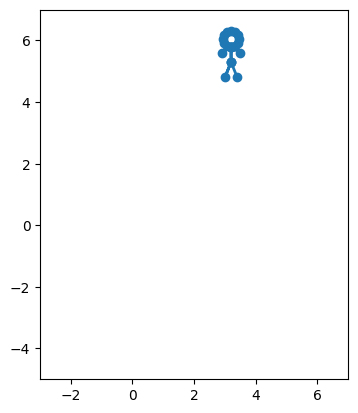

In [2]:
# Axis bounds
x_min, x_max = -3, 7
y_min, y_max = -5, 7

fig, ax = plt.subplots()
line, = ax.plot(X[0,:], X[1,:], 'o-', lw=2)
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_aspect('equal')

Y = X.copy()
for i in range(40):
    # Apply transformations
    Y = translate(Y, 0.08, 0.12)
    # Set back the line data
    line.set_xdata(Y[0,:])
    line.set_ydata(Y[1,:])

    # Refresh screen: clear -> display -> pause
    clear_output(wait=True)
    display(fig)
    plt.pause(0.1)
plt.close(fig)

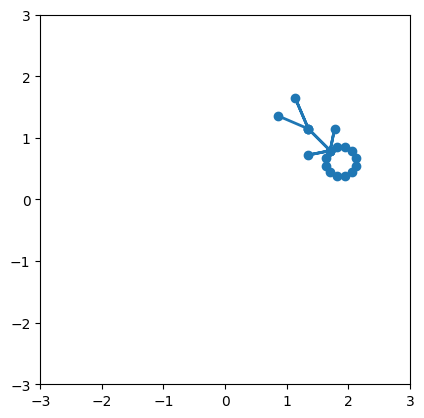

In [3]:
# Axis bounds
x_min, x_max = -3, 3
y_min, y_max = -3, 3

fig, ax = plt.subplots()
line, = ax.plot(X[0,:], X[1,:], 'o-', lw=2)
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_aspect('equal')

Y = X.copy()
Y = translate(Y, 1, 1.5)
for i in range(40):
    # Apply transformations
    Y = translate(Y, -1, -1.5)
    Y = rotate(Y, np.pi/32)
    Y = translate(Y, 1, 1.5)
    # Set back the line data
    line.set_xdata(Y[0,:])
    line.set_ydata(Y[1,:])

    # Refresh screen: clear -> display -> pause
    clear_output(wait=True)
    display(fig)
    plt.pause(0.1)
plt.close(fig)

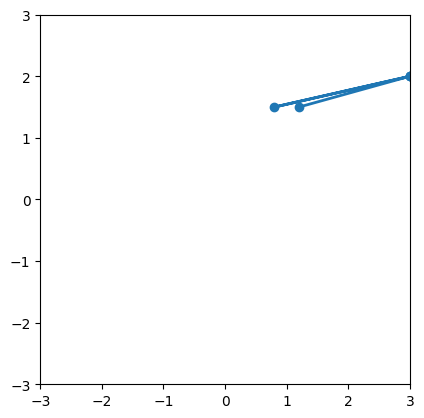

In [4]:
# Axis bounds
x_min, x_max = -3, 3
y_min, y_max = -3, 3

fig, ax = plt.subplots()
line, = ax.plot(X[0,:], X[1,:], 'o-', lw=2)
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_aspect('equal')

Y = X.copy()
Y = translate(Y, 1, 1.5)
for i in range(40):
    # Apply transformations
    Y = translate(Y, -1, -1.5)
    Y = shear_x(Y, 0.1)
    Y = translate(Y, 1, 1.5)
    # Set back the line data
    line.set_xdata(Y[0,:])
    line.set_ydata(Y[1,:])

    # Refresh screen: clear -> display -> pause
    clear_output(wait=True)
    display(fig)
    plt.pause(0.1)
plt.close(fig)

Rotate, translate and scale

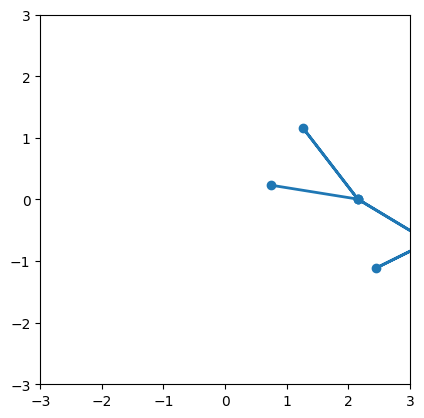

In [5]:
# Axis bounds
x_min, x_max = -3, 3
y_min, y_max = -3, 3

fig, ax = plt.subplots()
line, = ax.plot(X[0,:], X[1,:], 'o-', lw=2)
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_aspect('equal')

start_x = 1
start_y = 0.7

rotation_angle = np.pi/12
scale_x_factor = 1.02
scale_y_factor = 1.03

Y = X.copy()
Y = translate(Y, 1, 0.7)
for i in range(40):
    # Apply transformations
    Y = translate(Y, -start_x, -start_y)
    Y = rotate(Y, rotation_angle)
    Y = scale_x(Y, scale_x_factor)
    Y = scale_y(Y, scale_y_factor)
    Y = translate(Y, start_x, start_y)

    # Set back the line data
    line.set_xdata(Y[0,:])
    line.set_ydata(Y[1,:])

    # Refresh screen: clear -> display -> pause
    clear_output(wait=True)
    display(fig)
    plt.pause(0.1)
plt.close(fig)

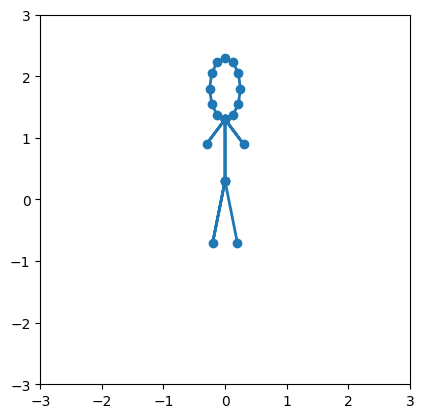

In [15]:
# Axis bounds
x_min, x_max = -3, 3
y_min, y_max = -3, 3

fig, ax = plt.subplots()
line, = ax.plot(X[0,:], X[1,:], 'o-', lw=2)
ax.set_xlim([x_min, x_max])
ax.set_ylim([y_min, y_max])
ax.set_aspect('equal')

start_x = 1
start_y = 0.7

scale_y_factor = 2

Y = X.copy()
Y = translate(Y, -start_x, -start_y)
Y = translate(Y, start_x, start_y)
display(fig)
plt.pause(1)

Y = X.copy()

# Apply transformations
Y = translate(Y, -start_x, -start_y)
Y = scale_y(Y, scale_y_factor)
Y = translate(Y, start_x, start_y)

# Set back the line data
line.set_xdata(Y[0,:])
line.set_ydata(Y[1,:])

# Refresh screen: clear -> display -> pause
clear_output(wait=True)
display(fig)
plt.close(fig)